# Environment Setup and Imports

In [1]:
import os
import time
import json
import warnings
from pathlib import Path
from copy import deepcopy
import numpy as np
import joblib
import h5py
from google.colab import drive

In [2]:
# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [3]:
# metrics from sklearn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

In [4]:
# visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [5]:
# reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : NVIDIA H100 80GB HBM3


In [7]:
# path configuration
drive.mount('/content/drive')
PROJECT_ROOT = Path("/content/drive/MyDrive/SU Works/CPSC_5310_Project")
DATA_PATH    = PROJECT_ROOT / "saved_data"
MODEL_PATH   = PROJECT_ROOT / "saved_models"
OUTPUT_PATH  = DATA_PATH / "lstm_outputs"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

HDF5_PATH   = DATA_PATH / "dl_tensors" / "dl_tensors.h5"
SCALER_PATH = MODEL_PATH / "dl_feature_scaler.pkl"

assert HDF5_PATH.exists(),   f"HDF5 not found: {HDF5_PATH}"
assert SCALER_PATH.exists(), f"Scaler not found: {SCALER_PATH}"

Mounted at /content/drive


# Loading Tensors and Metadata

In [8]:
with h5py.File(HDF5_PATH, "r") as f:
    # Tensors
    X_train = f["train/X"][:]          # float32  (N_train, 24, 13)
    y_train = f["train/y"][:]          # int8     (N_train,)  classes 1–5
    X_val   = f["val/X"][:]            # float32  (N_val, 24, 13)
    y_val   = f["val/y"][:]            # int8     (N_val,)
    X_test  = f["test/X"][:]           # float32  (N_test, 24, 13)
    y_test  = f["test/y"][:]           # int8     (N_test,)


    c_train = f["train/cluster_id"][:].astype(np.int64)   # (N_train,)
    c_val   = f["val/cluster_id"][:].astype(np.int64)     # (N_val,)
    c_test  = f["test/cluster_id"][:].astype(np.int64)    # (N_test,)

    # Metadata
    WINDOW_SIZE   = int(f.attrs["window_size"])     # 24
    NUM_FEATURES  = int(f.attrs["num_features"])    # updated by NB08 (now 15)
    NUM_CLUSTERS  = int(f.attrs["num_clusters"])    # 150
    FEATURE_NAMES = list(f.attrs["feature_names"])  # list[str]
    THRESHOLDS    = f.attrs["thresholds"]           # shape (4,)
    TRAIN_END     = f.attrs["train_end"]
    VAL_END       = f.attrs["val_end"]
    TEST_START    = f.attrs["test_start"]

scaler = joblib.load(SCALER_PATH)

# Override: read directly from tensor shape — source of truth
# NB08 now outputs 15 features (added lat_scaled, lon_scaled)
NUM_FEATURES = X_train.shape[2]
print(f"NUM_FEATURES overridden from tensor shape: {NUM_FEATURES}")

NUM_CLASSES = 5

print("─" * 52)
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print("─" * 52)
print(f"  Window  : {WINDOW_SIZE} hours,   Features : {NUM_FEATURES}")
print(f"  Clusters: {NUM_CLUSTERS}          Classes  : {NUM_CLASSES}")
print(f"  Train ends : {TRAIN_END}")
print(f"  Val ends   : {VAL_END}")
print(f"  Test starts: {TEST_START}")
print("─" * 52)
print("\nFeature index mapping:")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:2d}] {name}")

NUM_FEATURES overridden from tensor shape: 15
────────────────────────────────────────────────────
  X_train : (230400, 24, 15)   y_train : (230400,)
  X_val   : (28800, 24, 15)     y_val   : (28800,)
  X_test  : (64800, 24, 15)    y_test  : (64800,)
────────────────────────────────────────────────────
  Window  : 24 hours,   Features : 15
  Clusters: 150          Classes  : 5
  Train ends : 2016-03-05 23:00:00
  Val ends   : 2016-03-13 23:00:00
  Test starts: 2016-03-14 00:00:00
────────────────────────────────────────────────────

Feature index mapping:
  [ 0] demand_count
  [ 1] total_engaged_minutes
  [ 2] speed_mph
  [ 3] airport_trip_count
  [ 4] passenger_count
  [ 5] profit_index
  [ 6] neighbor_demand_mean
  [ 7] lat_scaled
  [ 8] lon_scaled
  [ 9] hour_sin
  [10] hour_cos
  [11] dow_sin
  [12] dow_cos
  [13] is_weekend
  [14] is_blizzard


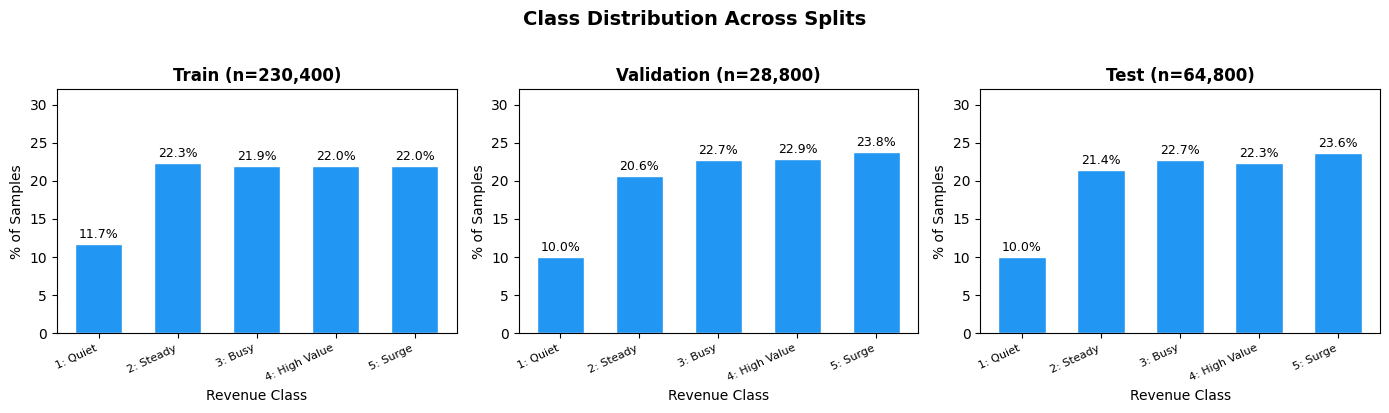

Note: Class 1 (~11%) is underrepresented → we use OrdinalCrossEntropyLoss (EMD) with balanced class weights.


In [9]:
CLASS_LABELS = ["1: Quiet", "2: Steady", "3: Busy", "4: High Value", "5: Surge"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (split_y, title) in zip(
    axes,
    [(y_train, "Train"), (y_val, "Validation"), (y_test, "Test")]
):
    counts = np.bincount(split_y, minlength=6)[1:]          # classes 1–5
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(range(1, 6), pcts, color="#2196F3", edgecolor="white", width=0.6)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{title} (n={len(split_y):,})", fontweight="bold")
    ax.set_xlabel("Revenue Class")
    ax.set_ylabel("% of Samples")
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(CLASS_LABELS, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 32)

fig.suptitle("Class Distribution Across Splits", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "class_distribution.png", bbox_inches="tight")
plt.show()
print("Note: Class 1 (~11%) is underrepresented → we use OrdinalCrossEntropyLoss (EMD) with balanced class weights.")

# Dataloaders

In [10]:
def make_loader(X: np.ndarray, y: np.ndarray, c: np.ndarray, batch_size: int = 512, shuffle: bool = False,):
    """
    Convert raw NumPy arrays to PyTorch TensorDataset to DataLoader.

    IMPORTANT: target, y is shifted from 1–5 to 0–4 here.
    CrossEntropyLoss expects 0-indexed class labels.
    """
    Xt = torch.tensor(X,   dtype=torch.float32)
    yt = torch.tensor(y-1, dtype=torch.long)          # target categories converted from 1-5 to 0-4
    ct = torch.tensor(c,   dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt, ct), batch_size=batch_size, shuffle=shuffle,
                      pin_memory=(DEVICE.type == "cuda"), num_workers=0)

In [11]:
y_train_0idx = y_train - 1
raw_weights  = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train_0idx,
)
CLASS_WEIGHTS = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

In [12]:
print("Class weights (balanced):")
for i, w in enumerate(raw_weights):
    print(f"  Class {i+1}: {w:.4f}")

# instantiate loaders
BATCH_SIZE   = 512
train_loader = make_loader(X_train, y_train, c_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   c_val,   batch_size=1024)
test_loader  = make_loader(X_test,  y_test,  c_test,  batch_size=1024)

print(f"\nBatches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Class weights (balanced):
  Class 1: 1.7043
  Class 2: 0.8952
  Class 3: 0.9120
  Class 4: 0.9093
  Class 5: 0.9091

Batches — train: 450  val: 29  test: 64


# LSTM Architecture

In [13]:
class DeepDispatchLSTM(nn.Module):
    """
    LSTM classifier for DeepDispatch revenue-class forecasting.

    Input
    -----
    x          : (batch, seq_len=24, num_features=15) — scaled feature sequence
    cluster_id : (batch,) — integer zone ID in [0, num_clusters)

    Output
    ------
    logits     : (batch, num_classes=5)  — raw (pre-softmax) scores
    """
    def __init__(
        self,
        num_features:  int   = 15,
        num_clusters:  int   = 150,
        embed_dim:     int   = 16,
        hidden_dim:    int   = 128,
        num_layers:    int   = 2,
        dropout:       float = 0.3,
        num_classes:   int   = 5,
    ):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers

        # Cluster embedding
        # Maps each zone ID to a dense vector; concatenated to every time step
        self.cluster_embed = nn.Embedding(
            num_embeddings=num_clusters,
            embedding_dim=embed_dim,
            padding_idx=None,
        )

        # Input projection
        # Project (num_features + embed_dim) → hidden_dim so the LSTM input
        # dimension is consistent regardless of embed_dim choice.
        input_dim = num_features + embed_dim
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )

        # LSTM stack
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,          # (batch, seq, feature)
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,       # causal — no future leakage
        )

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(hidden_dim // 2, num_classes),
        )

        self._init_weights()

    # Weight initialisation
    def _init_weights(self):
        for name, p in self.named_parameters():
            if "weight_ih" in name:           # LSTM input-hidden
                nn.init.xavier_uniform_(p)
            elif "weight_hh" in name:         # LSTM hidden-hidden
                nn.init.orthogonal_(p)
            elif "bias" in name:
                nn.init.zeros_(p)
                # Set forget-gate bias to 1 to ease gradient flow at start
                n = p.size(0)
                p.data[n//4 : n//2].fill_(1.0)

    # Forward pass
    def forward(
        self,
        x:          torch.Tensor,   # (B, T, F)
        cluster_id: torch.Tensor,   # (B,)
    ) -> torch.Tensor:
        B, T, _ = x.shape

        # Embed cluster, expand to every time step: (B, T, embed_dim)
        emb = self.cluster_embed(cluster_id)          # (B, embed_dim)
        emb = emb.unsqueeze(1).expand(-1, T, -1)      # (B, T, embed_dim)

        # Concatenate features + embedding: (B, T, F+embed_dim)
        x = torch.cat([x, emb], dim=-1)

        # Project to hidden_dim: (B, T, hidden_dim)
        x = self.input_proj(x)

        # LSTM: output=(B, T, hidden_dim), h_n=(num_layers, B, hidden_dim)
        _, (h_n, _) = self.lstm(x)

        # Take the top layer's final hidden state
        h_last = h_n[-1]                              # (B, hidden_dim)

        return self.head(h_last)                      # (B, num_classes)

    # Parameter count
    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick sanity-check forward pass
_model_check = DeepDispatchLSTM().to(DEVICE)
_x_dummy     = torch.zeros(4, 24, NUM_FEATURES, device=DEVICE)
_c_dummy     = torch.zeros(4, dtype=torch.long, device=DEVICE)
_out         = _model_check(_x_dummy, _c_dummy)
print(f"Output shape  : {_out.shape}   (expect [4, 5])")
print(f"Total params  : {_model_check.count_parameters():,}")
del _model_check, _x_dummy, _c_dummy, _out

Output shape  : torch.Size([4, 5])   (expect [4, 5])
Total params  : 279,781


# Training Infrustructure

In [14]:
# Evaluation helper
@torch.no_grad()
def evaluate(
    model:  nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> dict:
    """
    Return a dict of metrics computed on `loader`.
    Labels inside loader are already 0-indexed (0–4).
    Returned y_true / y_pred are restored to 1-indexed (1–5) for reporting.
    """
    model.eval()
    total_loss, all_preds, all_trues = 0.0, [], []

    for X_batch, y_batch, c_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        cids    = c_batch.to(DEVICE)

        logits = model(X_batch, cids)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)

        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_trues.append(y_batch.cpu().numpy())

    y_pred_0 = np.concatenate(all_preds)
    y_true_0 = np.concatenate(all_trues)

    # Restore 1-indexed for ordinal MAE / reporting
    y_pred = y_pred_0 + 1
    y_true = y_true_0 + 1

    avg_loss   = total_loss / len(y_true)
    acc        = accuracy_score(y_true, y_pred)
    w_f1       = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    m_f1       = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    mae        = np.abs(y_pred - y_true).mean()
    tol1       = (np.abs(y_pred - y_true) <= 1).mean()

    return dict(
        loss=avg_loss,
        accuracy=acc,
        weighted_f1=w_f1,
        macro_f1=m_f1,
        mae=mae,
        tol1=tol1,
        y_true=y_true,
        y_pred=y_pred,
    )

In [15]:
class OrdinalCrossEntropyLoss(nn.Module):
    """
    Ordinal-aware cross-entropy loss using Earth Mover's Distance (EMD).

    Standard CrossEntropyLoss penalises all wrong predictions equally:
    predicting class 1 when truth is 5 gets the same penalty as predicting
    class 4 when truth is 5. This is wrong for an ordinal scale.

    EMD Loss fixes this by computing the cumulative distribution distance
    between the predicted probability distribution and the one-hot target.
    A prediction that is "close" on the ordinal scale gets a smaller penalty.

    How it works
    ────────────
    For K classes, the one-hot CDF of class k is a step function that is 0
    for all positions < k and 1 for all positions ≥ k. The model's predicted
    CDF is the cumulative sum of its softmax probabilities. The EMD is the
    L2 distance between these two CDFs, averaged over the K-1 threshold
    positions. This is exactly the Wasserstein-1 distance for 1-D ordinals.

    Class weights are applied at the sample level before averaging, so
    the existing balanced-class weighting is preserved.

    Parameters
    ----------
    class_weights : (K,) FloatTensor — same as used in CrossEntropyLoss
    num_classes   : int — K
    """
    def __init__(self, class_weights: torch.Tensor, num_classes: int = 5):
        super().__init__()
        self.register_buffer('class_weights', class_weights)
        self.num_classes = num_classes

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        logits  : (B, K) — raw model outputs (pre-softmax)
        targets : (B,)   — ground-truth class indices, 0-indexed (0 to K-1)
        """
        B, K = logits.shape

        # Predicted CDF: cumulative sum of softmax probabilities
        # Shape: (B, K)
        probs     = torch.softmax(logits, dim=-1)
        pred_cdf  = torch.cumsum(probs, dim=-1)          # (B, K)

        # True CDF: step function — 0 before target class, 1 at and after
        # Shape: (B, K)
        class_idx  = torch.arange(K, device=logits.device).unsqueeze(0)  # (1, K)
        true_cdf   = (class_idx >= targets.unsqueeze(1)).float()          # (B, K)

        # EMD = mean squared CDF distance over K-1 thresholds (drop the last
        # column because both CDFs always equal 1 there — it contributes 0)
        emd_per_sample = ((pred_cdf[:, :-1] - true_cdf[:, :-1]) ** 2).mean(dim=-1)  # (B,)

        # Apply class weights at the sample level
        sample_weights = self.class_weights[targets]     # (B,)
        loss = (emd_per_sample * sample_weights).sum() / sample_weights.sum()
        return loss


# Instantiate once — shared by train_model and evaluate
ORDINAL_CRITERION = OrdinalCrossEntropyLoss(
    class_weights=CLASS_WEIGHTS,
    num_classes=NUM_CLASSES,
).to(DEVICE)

print("OrdinalCrossEntropyLoss (EMD) instantiated ✓")
print(f"  Replaces: CrossEntropyLoss (treats all misclassifications equally)")
print(f"  Effect  : predicting class 4 when truth is 5 gets ~4x less penalty")
print(f"            than predicting class 1 when truth is 5")


OrdinalCrossEntropyLoss (EMD) instantiated ✓
  Replaces: CrossEntropyLoss (treats all misclassifications equally)
  Effect  : predicting class 4 when truth is 5 gets ~4x less penalty
            than predicting class 1 when truth is 5


In [16]:
def train_model(
    model:       nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    *,
    lr:           float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs:   int   = 60,
    patience:     int   = 8,
    checkpoint_path: Path,
) -> dict:
    """
    Full training loop with early stopping on validation weighted-F1.

    Returns
    -------
    history : dict with lists of per-epoch metrics
    """
    criterion = ORDINAL_CRITERION   # EMD ordinal loss — penalises large class gaps more
    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(
        optimiser, mode="max", factor=0.5, patience=4
    )

    best_val_f1   = -np.inf
    best_state    = None
    no_improve    = 0
    history       = {k: [] for k in [
        "train_loss", "val_loss",
        "train_acc",  "val_acc",
        "train_wf1",  "val_wf1",
        "lr",
    ]}

    print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>9} "
          f"{'TrainAcc':>9} {'ValAcc':>8} {'ValWF1':>7} {'LR':>9} {'':>4}")
    print("─" * 72)

    for epoch in range(1, max_epochs + 1):
        # Training
        model.train()
        epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0
        t0 = time.time()

        for X_batch, y_batch, c_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            cids    = c_batch.to(DEVICE)

            optimiser.zero_grad()
            logits = model(X_batch, cids)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()

            epoch_loss    += loss.item() * len(y_batch)
            epoch_correct += (logits.argmax(1) == y_batch).sum().item()
            epoch_total   += len(y_batch)

        train_loss = epoch_loss / epoch_total
        train_acc  = epoch_correct / epoch_total

        # Validation
        val_metrics  = evaluate(model, val_loader, criterion)
        val_loss     = val_metrics["loss"]
        val_acc      = val_metrics["accuracy"]
        val_wf1      = val_metrics["weighted_f1"]

        current_lr   = optimiser.param_groups[0]["lr"]
        scheduler.step(val_wf1)

        # Early stopping
        improved = val_wf1 > best_val_f1 + 1e-5
        if improved:
            best_val_f1 = val_wf1
            best_state  = deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            no_improve  = 0
            marker      = "✓"
        else:
            no_improve += 1
            marker      = f"({no_improve}/{patience})"

        # Record history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_wf1"].append(
            f1_score(y_train - 1,
                     np.zeros(len(y_train), dtype=int),   # placeholder — expensive to recompute
                     average="weighted", zero_division=0)
            if False else 0.0  # skip expensive train-F1 per epoch for speed
        )
        history["train_wf1"][-1] = float(train_acc)  # use acc as proxy in history
        history["val_wf1"].append(val_wf1)
        history["lr"].append(current_lr)

        elapsed = time.time() - t0
        print(f"{epoch:5d} {train_loss:10.4f} {val_loss:9.4f} "
              f"{train_acc:9.4f} {val_acc:8.4f} {val_wf1:7.4f} "
              f"{current_lr:9.2e}  {marker}")

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} — no improvement for {patience} epochs.")
            break

    # Restore best weights
    model.load_state_dict(best_state)
    print(f"\nBest val weighted-F1: {best_val_f1:.4f}")
    return history

# Hyperparameter Experimentation

In [17]:
CONFIGS = {
    "compact":  dict(hidden_dim=64,  num_layers=1, dropout=0.45, embed_dim=8),
    "standard": dict(hidden_dim=128, num_layers=2, dropout=0.5, embed_dim=16),
    "large":    dict(hidden_dim=256, num_layers=2, dropout=0.5, embed_dim=32),
}

TRAIN_KWARGS = dict(
    lr=1e-3,
    weight_decay=1e-3,
    max_epochs=100,
    patience=15,
)

all_histories = {}
all_val_results = {}

for cfg_name, cfg_kwargs in CONFIGS.items():
    print("\n" + "═" * 92)
    print(f"  CONFIG: {cfg_name.upper()}  |  {cfg_kwargs}")
    print("═" * 92)

    model = DeepDispatchLSTM(
        num_features=NUM_FEATURES,
        num_clusters=NUM_CLUSTERS,
        num_classes=NUM_CLASSES,
        **cfg_kwargs,
    ).to(DEVICE)
    print(f"  Parameters: {model.count_parameters():,}\n")

    ckpt_path = OUTPUT_PATH / f"lstm_{cfg_name}_best.pt"
    history   = train_model(
        model, train_loader, val_loader,
        checkpoint_path=ckpt_path,
        **TRAIN_KWARGS,
    )
    all_histories[cfg_name]   = history

    # Evaluate on validation with best checkpoint
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    val_res = evaluate(model, val_loader, ORDINAL_CRITERION)
    all_val_results[cfg_name] = val_res

    print(f"\n  Val → Acc: {val_res['accuracy']:.4f}  "
          f"WF1: {val_res['weighted_f1']:.4f}  "
          f"MF1: {val_res['macro_f1']:.4f}  "
          f"MAE: {val_res['mae']:.4f}")


════════════════════════════════════════════════════════════════════════════════════════════
  CONFIG: COMPACT  |  {'hidden_dim': 64, 'num_layers': 1, 'dropout': 0.45, 'embed_dim': 8}
════════════════════════════════════════════════════════════════════════════════════════════
  Parameters: 38,517

Epoch  TrainLoss   ValLoss  TrainAcc   ValAcc  ValWF1        LR     
────────────────────────────────────────────────────────────────────────
    1     0.0794    0.0616    0.5895   0.6964  0.6949  1.00e-03  ✓
    2     0.0553    0.0567    0.7029   0.7266  0.7278  1.00e-03  ✓
    3     0.0507    0.0576    0.7263   0.7177  0.7152  1.00e-03  (1/15)
    4     0.0482    0.0530    0.7385   0.7462  0.7458  1.00e-03  ✓
    5     0.0466    0.0528    0.7477   0.7503  0.7520  1.00e-03  ✓
    6     0.0458    0.0548    0.7520   0.7342  0.7348  1.00e-03  (1/15)
    7     0.0449    0.0517    0.7568   0.7529  0.7541  1.00e-03  ✓
    8     0.0443    0.0516    0.7597   0.7593  0.7592  1.00e-03  ✓
    9     0.

In [18]:
# Pick best config by validation weighted-F1
BEST_CFG = max(all_val_results, key=lambda k: all_val_results[k]["weighted_f1"])
print(f"Best configuration: '{BEST_CFG}'")
print(f"  Val Acc    : {all_val_results[BEST_CFG]['accuracy']:.4f}")
print(f"  Val Wt. F1 : {all_val_results[BEST_CFG]['weighted_f1']:.4f}")

# Reload best model
best_model = DeepDispatchLSTM(
    num_features=NUM_FEATURES,
    num_clusters=NUM_CLUSTERS,
    num_classes=NUM_CLASSES,
    **CONFIGS[BEST_CFG],
).to(DEVICE)
best_model.load_state_dict(
    torch.load(OUTPUT_PATH / f"lstm_{BEST_CFG}_best.pt", map_location=DEVICE)
)
best_model.eval()
print(f"\nBest model loaded from checkpoint.")

Best configuration: 'standard'
  Val Acc    : 0.7786
  Val Wt. F1 : 0.7795

Best model loaded from checkpoint.


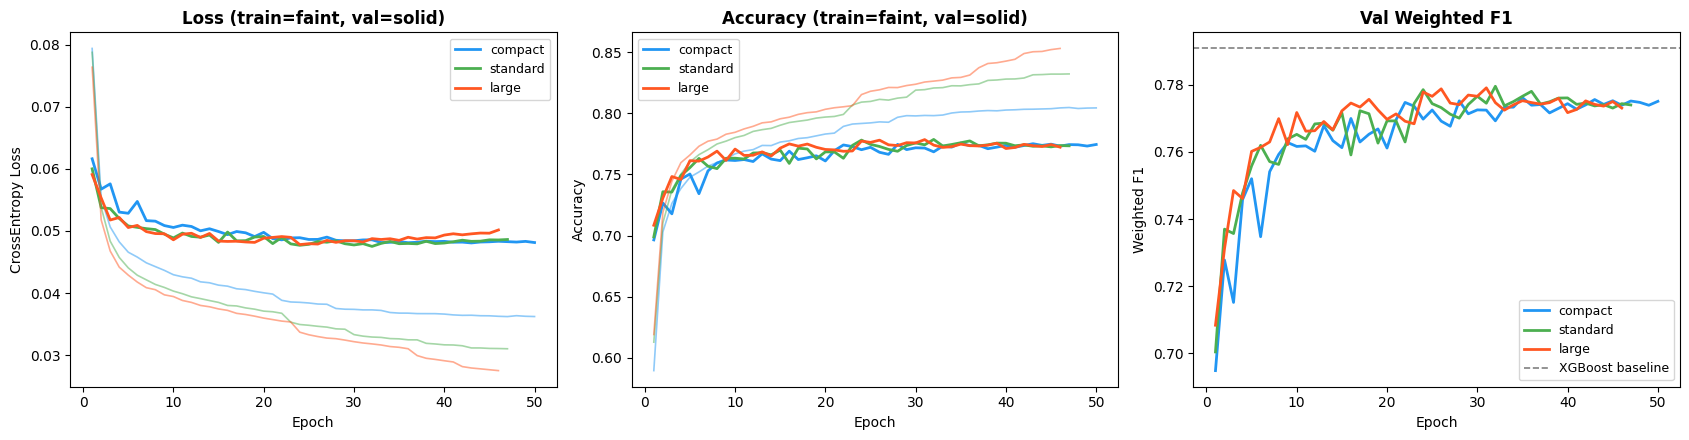

In [19]:
ig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
palette   = {"compact": "#2196F3", "standard": "#4CAF50", "large": "#FF5722"}

for cfg_name, hist in all_histories.items():
    color = palette[cfg_name]
    n     = len(hist["val_loss"])
    ep    = range(1, n + 1)

    axes[0].plot(ep, hist["train_loss"], color=color, lw=1.2, alpha=0.5)
    axes[0].plot(ep, hist["val_loss"],   color=color, lw=2,   label=cfg_name)
    axes[1].plot(ep, hist["train_acc"],  color=color, lw=1.2, alpha=0.5)
    axes[1].plot(ep, hist["val_acc"],    color=color, lw=2,   label=cfg_name)
    axes[2].plot(ep, hist["val_wf1"],    color=color, lw=2,   label=cfg_name)

for ax, title, ylabel in zip(
    axes,
    ["Loss (train=faint, val=solid)", "Accuracy (train=faint, val=solid)", "Val Weighted F1"],
    ["CrossEntropy Loss", "Accuracy", "Weighted F1"],
):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

# Baseline reference line
axes[2].axhline(0.7908, color="gray", ls="--", lw=1.2, label="XGBoost baseline")
axes[2].legend(fontsize=9)

fig.suptitle("DeepDispatch LSTM — Training Curves (All Configs)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "training_curves.png", bbox_inches="tight")
plt.show()

In [20]:
# Run final evaluation
criterion_eval = ORDINAL_CRITERION
test_metrics   = evaluate(best_model, test_loader, criterion_eval)

print("\n" + "═" * 52)
print("  FINAL TEST SET RESULTS — DeepDispatch LSTM")
print("═" * 52)
print(f"  Config          : {BEST_CFG}")
print(f"  Test Accuracy   : {test_metrics['accuracy']:.4f}  ({test_metrics['accuracy']*100:.2f}%)")
print(f"  Weighted F1     : {test_metrics['weighted_f1']:.4f}")
print(f"  Macro F1        : {test_metrics['macro_f1']:.4f}")
print(f"  MAE (ordinal)   : {test_metrics['mae']:.4f}")
print(f"  1-class Tol.    : {test_metrics['tol1']:.4f}  ({test_metrics['tol1']*100:.2f}%)")
print("─" * 52)
print("  XGBoost baseline: Acc=79.12%  WF1=0.7908  MAE=0.2119")
print("═" * 52)

# Delta vs baseline
delta_acc = test_metrics['accuracy'] - 0.7912
delta_wf1 = test_metrics['weighted_f1'] - 0.7908
sign_acc  = "+" if delta_acc >= 0 else ""
sign_wf1  = "+" if delta_wf1 >= 0 else ""
print(f"\n  Δ vs XGBoost → Accuracy: {sign_acc}{delta_acc*100:.2f}pp  "
      f"Weighted F1: {sign_wf1}{delta_wf1:.4f}")


════════════════════════════════════════════════════
  FINAL TEST SET RESULTS — DeepDispatch LSTM
════════════════════════════════════════════════════
  Config          : standard
  Test Accuracy   : 0.7844  (78.44%)
  Weighted F1     : 0.7849
  Macro F1        : 0.7824
  MAE (ordinal)   : 0.2260
  1-class Tol.    : 0.9932  (99.32%)
────────────────────────────────────────────────────
  XGBoost baseline: Acc=79.12%  WF1=0.7908  MAE=0.2119
════════════════════════════════════════════════════

  Δ vs XGBoost → Accuracy: -0.68pp  Weighted F1: -0.0059


In [21]:
# Cross-model comparison table
import pandas as pd

results_table = pd.DataFrame([
    {"Model": "Naive Baseline (Cluster+Hour)", "Test Acc": "68.91%", "Wt. F1": "0.6900",
     "Macro F1": "0.6900", "MAE": "—",    "1-cls Tol": "—"},
    {"Model": "Logistic Regression",           "Test Acc": "75.36%", "Wt. F1": "0.7522",
     "Macro F1": "0.7500", "MAE": "0.2513", "1-cls Tol": "—"},
    {"Model": "Random Forest",                 "Test Acc": "78.41%", "Wt. F1": "0.7838",
     "Macro F1": "0.7800", "MAE": "0.2194", "1-cls Tol": "—"},
    {"Model": "XGBoost (Tuned)",               "Test Acc": "79.12%", "Wt. F1": "0.7908",
     "Macro F1": "0.7900", "MAE": "0.2119", "1-cls Tol": "99.74%"},
    {"Model": f"LSTM ({BEST_CFG}) ← THIS",
     "Test Acc":  f"{test_metrics['accuracy']*100:.2f}%",
     "Wt. F1":   f"{test_metrics['weighted_f1']:.4f}",
     "Macro F1": f"{test_metrics['macro_f1']:.4f}",
     "MAE":      f"{test_metrics['mae']:.4f}",
     "1-cls Tol":f"{test_metrics['tol1']*100:.2f}%"},
])

results_table = results_table.set_index("Model")
print("\nFull Model Comparison:")
print(results_table.to_string())

results_table.to_csv(OUTPUT_PATH / "model_comparison.csv")


Full Model Comparison:
                              Test Acc  Wt. F1 Macro F1     MAE 1-cls Tol
Model                                                                    
Naive Baseline (Cluster+Hour)   68.91%  0.6900   0.6900       —         —
Logistic Regression             75.36%  0.7522   0.7500  0.2513         —
Random Forest                   78.41%  0.7838   0.7800  0.2194         —
XGBoost (Tuned)                 79.12%  0.7908   0.7900  0.2119    99.74%
LSTM (standard) ← THIS          78.44%  0.7849   0.7824  0.2260    99.32%


# Error Analysis

In [22]:
y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

#  Per-class metrics
print("Per-class Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_LABELS,
    digits=4,
))

Per-class Classification Report:
               precision    recall  f1-score   support

     1: Quiet     0.7096    0.8496    0.7733      6502
    2: Steady     0.7739    0.7385    0.7558     13845
      3: Busy     0.7460    0.7294    0.7376     14690
4: High Value     0.7463    0.7709    0.7584     14464
     5: Surge     0.9113    0.8636    0.8868     15299

     accuracy                         0.7844     64800
    macro avg     0.7774    0.7904    0.7824     64800
 weighted avg     0.7874    0.7844    0.7849     64800



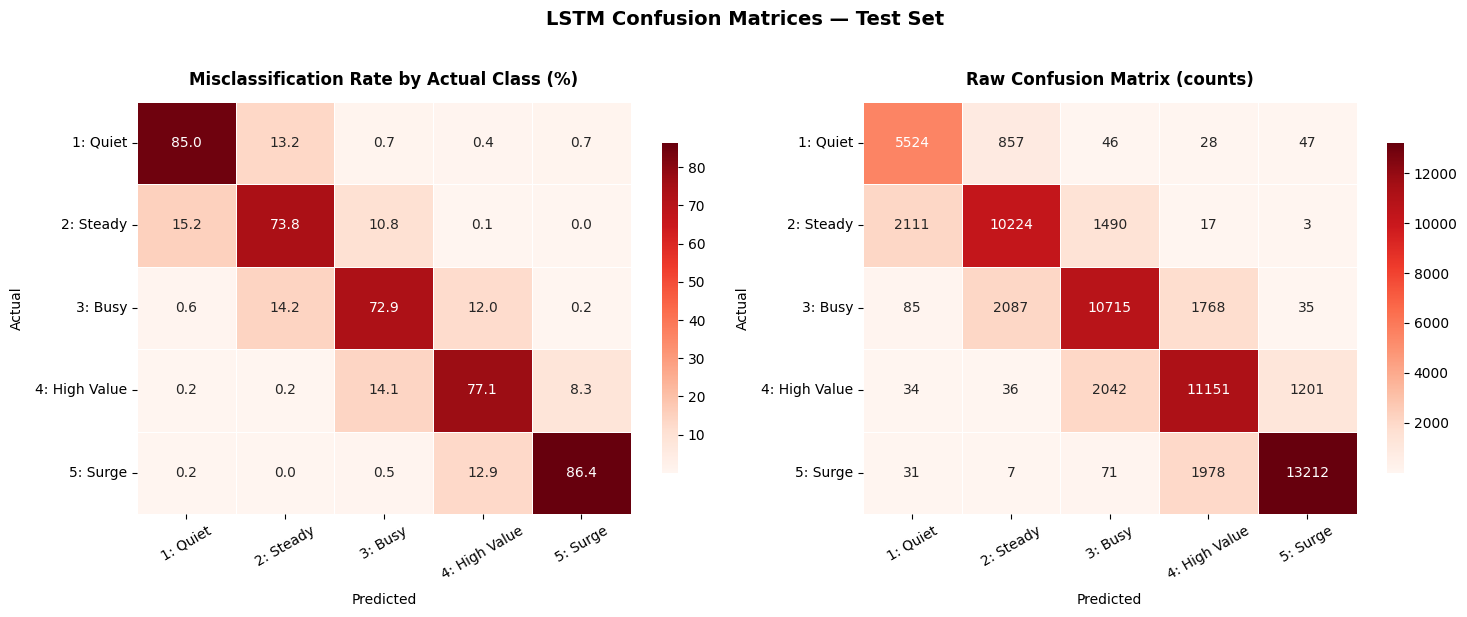

In [23]:
#  Confusion matrix (normalised by actual class)
cm_raw  = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, cm, fmt, title in zip(
    axes,
    [cm_norm * 100, cm_raw],
    [".1f", "d"],
    ["Misclassification Rate by Actual Class (%)", "Raw Confusion Matrix (counts)"],
):
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Reds",
        xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted", labelpad=8)
    ax.set_ylabel("Actual",    labelpad=8)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("LSTM Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "confusion_matrix.png", bbox_inches="tight")
plt.show()

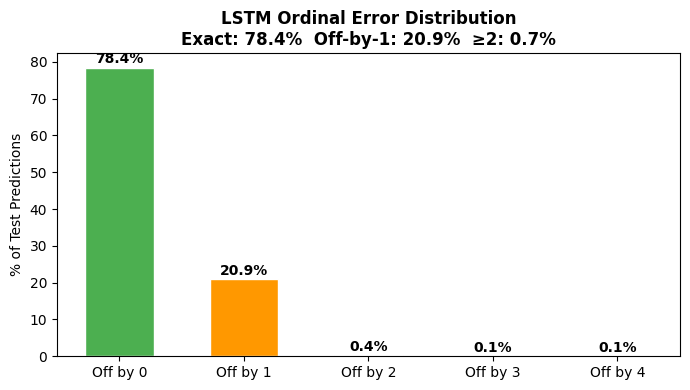

Comparison vs XGBoost baseline:
  XGBoost  → Exact: 79.1%  Off-by-1: 20.6%  ≥2: 0.3%
  LSTM     → Exact: 78.4%  Off-by-1: 20.9%  ≥2: 0.7%


In [24]:
# Ordinal error distribution
errors     = np.abs(y_pred - y_true)
error_dist = {int(e): float((errors == e).mean() * 100) for e in sorted(np.unique(errors))}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    list(error_dist.keys()),
    list(error_dist.values()),
    color=["#4CAF50" if k == 0 else "#FF9800" if k == 1 else "#F44336" for k in error_dist],
    edgecolor="white",
    width=0.55,
)
for bar, pct in zip(bars, error_dist.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")

ax.set_xticks(list(error_dist.keys()))
ax.set_xticklabels([f"Off by {k}" for k in error_dist.keys()])
ax.set_ylabel("% of Test Predictions")
ax.set_title(f"LSTM Ordinal Error Distribution\n"
             f"Exact: {error_dist.get(0, 0):.1f}%  "
             f"Off-by-1: {error_dist.get(1, 0):.1f}%  "
             f"≥2: {sum(v for k,v in error_dist.items() if k>=2):.1f}%",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "ordinal_error_distribution.png", bbox_inches="tight")
plt.show()

print("Comparison vs XGBoost baseline:")
print(f"  XGBoost  → Exact: 79.1%  Off-by-1: 20.6%  ≥2: 0.3%")
print(f"  LSTM     → Exact: {error_dist.get(0,0):.1f}%  "
      f"Off-by-1: {error_dist.get(1,0):.1f}%  "
      f"≥2: {sum(v for k,v in error_dist.items() if k>=2):.1f}%")

In [25]:
FINAL_MODEL_PATH = MODEL_PATH / "lstm_final.pt"
torch.save({
    "model_state_dict":   best_model.state_dict(),
    "config":             CONFIGS[BEST_CFG],
    "best_config_name":   BEST_CFG,
    "num_features":       NUM_FEATURES,
    "num_clusters":       NUM_CLUSTERS,
    "num_classes":        NUM_CLASSES,
    "feature_names":      FEATURE_NAMES,
    "window_size":        WINDOW_SIZE,
    "test_metrics": {
        k: v for k, v in test_metrics.items()
        if k not in ("y_true", "y_pred")    # exclude large arrays
    },
}, FINAL_MODEL_PATH)
print(f"Saved: {FINAL_MODEL_PATH}")

metrics_dict = {
    "model":        f"LSTM-{BEST_CFG}",
    "config":       CONFIGS[BEST_CFG],
    "test_accuracy":    round(float(test_metrics["accuracy"]),     4),
    "weighted_f1":      round(float(test_metrics["weighted_f1"]),  4),
    "macro_f1":         round(float(test_metrics["macro_f1"]),     4),
    "mae_ordinal":      round(float(test_metrics["mae"]),          4),
    "tol1_accuracy":    round(float(test_metrics["tol1"]),         4),
    "xgboost_baseline": {"accuracy": 0.7912, "weighted_f1": 0.7908, "mae": 0.2119},
}
with open(OUTPUT_PATH / "lstm_test_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=2)

print(f"Saved: {OUTPUT_PATH / 'lstm_test_metrics.json'}")

print("\n" + "═" * 52)
print("  NOTEBOOK 09 COMPLETE")
print("═" * 52)
print(f"  Best config  : {BEST_CFG}")
print(f"  Test Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"  Weighted F1  : {test_metrics['weighted_f1']:.4f}")
print(f"  MAE (ordinal): {test_metrics['mae']:.4f}")
print(f"  1-class tol  : {test_metrics['tol1']*100:.2f}%")
print("─" * 52)
print("  Artifacts saved to:", OUTPUT_PATH)
print("  ├─ lstm_final.pt")
print("  ├─ lstm_test_metrics.json")
print("  ├─ model_comparison.csv")
print("  ├─ training_curves.png")
print("  ├─ confusion_matrix.png")
print("  ├─ ordinal_error_distribution.png")
print("  └─ revenue_heatmap_preview.png")
print("═" * 52)

Saved: /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_models/lstm_final.pt
Saved: /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/lstm_outputs/lstm_test_metrics.json

════════════════════════════════════════════════════
  NOTEBOOK 09 COMPLETE
════════════════════════════════════════════════════
  Best config  : standard
  Test Accuracy: 78.44%
  Weighted F1  : 0.7849
  MAE (ordinal): 0.2260
  1-class tol  : 99.32%
────────────────────────────────────────────────────
  Artifacts saved to: /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/lstm_outputs
  ├─ lstm_final.pt
  ├─ lstm_test_metrics.json
  ├─ model_comparison.csv
  ├─ training_curves.png
  ├─ confusion_matrix.png
  ├─ ordinal_error_distribution.png
  └─ revenue_heatmap_preview.png
════════════════════════════════════════════════════
